# Import Data



In [7]:
import sys
print(sys.executable)


/opt/anaconda3/bin/python


In [8]:
import sys
!{sys.executable} -m pip install nibabel nilearn numpy scipy pandas matplotlib scikit-learn


224.19s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


## nibabel

In [9]:
import sys
!{sys.executable} -m pip install nibabel


232.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [10]:
import nibabel as nib

nii_path = "/Users/dumengpro/Desktop/Leiden Uni/fmri/Example_practice/p_s0002_rs1_4mm.nii"
img = nib.load(nii_path)



In [11]:
print(img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (45, 54, 45, 220)
affine:
[[  -4.    0.    0.   90.]
 [   0.    4.    0. -126.]
 [   0.    0.    4.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  45  54  45 220   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.  4.  4.  4.  1.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 37
slice_code      : unknown
xyzt_units      : 10
cal_max         : 26138.195
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL4.0\x00 Medical Systems Achieva 2.6.1 '
aux_file 

In [12]:
data_exa=img.get_fdata()

data_exa.shape
# (x,y,z,t)=(45,54,45,220)

(45, 54, 45, 220)

In [13]:
header=img.header
affine=img.affine

print(header.get_zooms()) 
# voxel size=4*4*4 and TR=1.0

(4.0, 4.0, 4.0, 1.0)


In [14]:
if data_exa.ndim==4:
    print("This is fMRI data (4D).")
    
else:
    print("This is not fMRI")

This is fMRI data (4D).


In [15]:
data_exa.shape[2] #45，Z维的长度
data_exa.shape[2]//2 # 22:去中间的一层

22

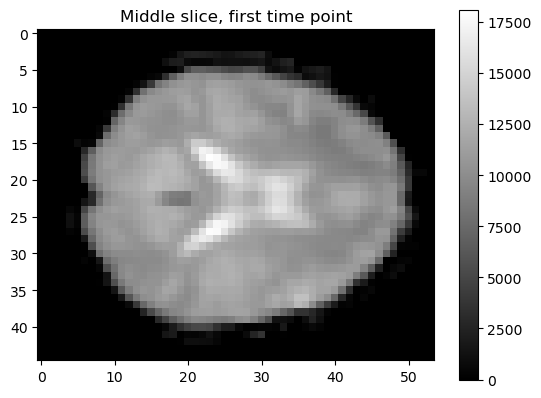

In [16]:
import matplotlib.pyplot as plt

plt.imshow(data_exa[:, :, data_exa.shape[2]//2, 0], cmap="gray") # 取所有的X，Y，Z的中间那一层，t=0的时候的切片
plt.colorbar()
plt.title("Middle slice, first time point")
plt.show()


## nilearn

In [17]:
import sys
!{sys.executable} -m pip install nilearn


252.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


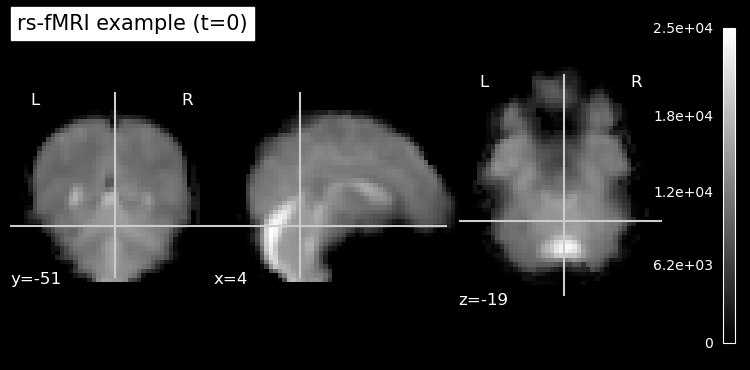

In [18]:
from nilearn import plotting, image

plotting.plot_epi(image.index_img(img, 0), title="rs-fMRI example (t=0)")

#index_img(img, 0)，取t=0的维度的3D切片


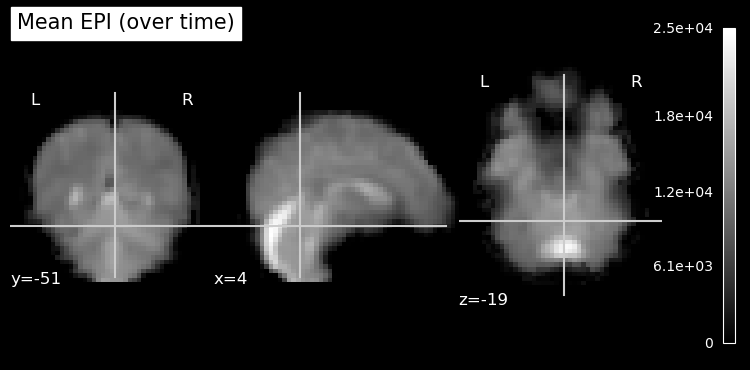

In [19]:
# 画一个平均图
from nilearn import plotting, image

mean_img = image.mean_img(img)
plotting.plot_epi(mean_img, title="Mean EPI (over time)")


In [20]:
#确认数据是几维
print(img.shape)


(45, 54, 45, 220)


In [21]:
tr = img.header.get_zooms()[3]
print("TR =", tr)


TR = 1.0


# FC matrices

In [22]:
print("img shape:", img.shape)
print("zooms (voxel size +TR):", img.header.get_zooms())

img shape: (45, 54, 45, 220)
zooms (voxel size +TR): (4.0, 4.0, 4.0, 1.0)


## AAL atlas (most classic)
解剖分区，最经典

In [23]:
import sys
!{sys.executable} -m pip install -U certifi


275.46s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [24]:
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
print("Using SSL cert file:", os.environ["SSL_CERT_FILE"])


Using SSL cert file: /opt/anaconda3/lib/python3.12/site-packages/certifi/cacert.pem


In [25]:
from nilearn import datasets
aal = datasets.fetch_atlas_aal(version="SPM12")


[fetch_atlas_aal] Dataset found in /Users/dumengpro/nilearn_data/aal_SPM12

[fetch_atlas_aal] Downloading data from https://www.gin.cnrs.fr/AAL_files/aal_for_SPM12.tar.gz ...

[fetch_atlas_aal] Error while fetching file aal_for_SPM12.tar.gz; dataset fetching aborted.

SSLError: HTTPSConnectionPool(host='www.gin.cnrs.fr', port=443): Max retries exceeded with url: /AAL_files/aal_for_SPM12.tar.gz (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)')))

In [1]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

aal = datasets.fetch_atlas_aal(version="SPM12")  # 下载AAL atlas，aal.maps 是label图
masker = NiftiLabelsMasker(
    labels_img=aal.maps,
    standardize=True,     # 对每个ROI时间序列做z-score（常用）
    detrend=True,         # 去线性趋势（常用）
    low_pass=None, high_pass=None, t_r=None  # 如果你已在预处理做了滤波，这里先不做
)

ts = masker.fit_transform(img)  # 真正开始提取ROI time series，shape: (T, N_ROI)
print("time series shape (T, N_ROI):", ts.shape)


[fetch_atlas_aal] Dataset found in /Users/dumengpro/nilearn_data/aal_SPM12

[fetch_atlas_aal] Downloading data from https://www.gin.cnrs.fr/AAL_files/aal_for_SPM12.tar.gz ...

[fetch_atlas_aal] Error while fetching file aal_for_SPM12.tar.gz; dataset fetching aborted.

SSLError: HTTPSConnectionPool(host='www.gin.cnrs.fr', port=443): Max retries exceeded with url: /AAL_files/aal_for_SPM12.tar.gz (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)')))

## Schaeffer atlas
功能分区，现代论文常用

In [ ]:
# 这个需要你选择 ROI 数，比如 200 或 400

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker

schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7, resolution_mm=2)
masker = NiftiLabelsMasker(
    labels_img=schaefer.maps,
    standardize=True,
    detrend=True,
    low_pass=None, high_pass=None, t_r=None
)

ts = masker.fit_transform(img)
print("time series shape (T, N_ROI):", ts.shape)
# time series shape (T, N_ROI): (220, 200)

[fetch_atlas_schaefer_2018] Dataset found in /Users/dumengpro/nilearn_data/schaefer_2018

/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_24441/3764422044.py:14: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(img)


time series shape (T, N_ROI): (220, 200)


In [30]:
ts

array([[ 1.3710032 ,  1.1917062 ,  1.5762215 , ..., -0.3254587 ,
        -0.05996086,  0.7482947 ],
       [ 1.0527824 ,  1.6280278 ,  1.5479872 , ..., -0.91727287,
        -0.40069035,  0.11971285],
       [ 1.0630676 ,  1.736233  ,  1.632731  , ..., -0.464681  ,
         0.22933789,  0.14988299],
       ...,
       [-0.6911897 ,  0.26948172,  0.7902154 , ...,  0.38211486,
         1.23434   ,  0.6891333 ],
       [-0.36343104,  0.356765  ,  0.48983258, ...,  0.09725054,
         1.183031  ,  0.60016114],
       [ 0.16742764,  0.699398  ,  0.52511287, ..., -0.5671949 ,
         1.0049341 ,  0.60879743]], dtype=float32)

## Calculate FC matrix

In [27]:
from nilearn.connectome import ConnectivityMeasure
import numpy as np

conn = ConnectivityMeasure(kind="correlation")     # Pearson相关
fc = conn.fit_transform([ts])[0]                  # shape: (N_ROI, N_ROI)

print("FC shape:", fc.shape)
print("FC diag (should be 1s):", np.round(np.diag(fc)[:5], 3))


FC shape: (200, 200)
FC diag (should be 1s): [1. 1. 1. 1. 1.]


/var/folders/rx/_kz_6d2d7kq57d6fkgrbnrk00000gn/T/ipykernel_24441/3404640506.py:5: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  fc = conn.fit_transform([ts])[0]                  # shape: (N_ROI, N_ROI)


In [28]:
# Fisher z变换
fc_z = np.arctanh(np.clip(fc, -0.999999, 0.999999))


## 画出FC matrix

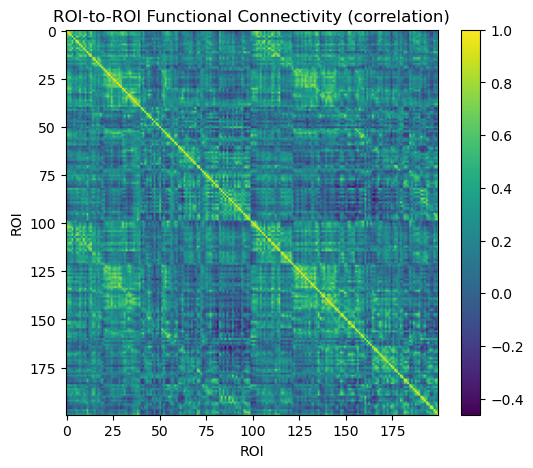

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(fc, aspect="auto")
plt.colorbar()
plt.title("ROI-to-ROI Functional Connectivity (correlation)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.show()


## 保存统计结果

In [ ]:

# import numpy as np
# np.save("fc_matrix.npy", fc)
# np.savetxt("fc_matrix.csv", fc, delimiter=",")
